In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




print('Libraries loaded')

Libraries loaded


In [ ]:
file_path = 'D:\DS Assignment\Basic stats - 1\Basic stats - 1/sales_data_with_discounts.csv'
df = pd.read_csv(file_path)

print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)

df.head(10)

Shape: (450, 13)

Data types:
Date                  object
Day                   object
SKU                   object
City                  object
Volume                 int64
BU                    object
Brand                 object
Model                 object
Avg Price              int64
Total Sales Value      int64
Discount Rate (%)    float64
Discount Amount      float64
Net Sales Value      float64
dtype: object


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770
5,01-04-2021,Thursday,M06,C,3,Mobiles,RealU,RU-9,8100,24300,16.996489,4130.146805,20169.853195
6,01-04-2021,Thursday,M07,C,3,Mobiles,Sumsang,S-20,49100,147300,9.228812,13594.039719,133705.960281
7,01-04-2021,Thursday,M08,C,2,Mobiles,Sumsang,S-21,54100,108200,5.553719,6009.124321,102190.875679
8,01-04-2021,Thursday,M09,C,2,Mobiles,Orange,O-10,55100,110200,7.410104,8165.935144,102034.064856
9,01-04-2021,Thursday,M10,C,3,Mobiles,Orange,O-11,60100,180300,9.928444,17900.983733,162399.016267


In [3]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print('Numerical columns:', num_cols)
print('Categorical columns:', cat_cols)

Numerical columns: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']
Categorical columns: ['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


In [ ]:
stats = []
for col in num_cols:
    col_series = df[col].dropna()
    mean = col_series.mean()
    median = col_series.median()
    try:
        mode = col_series.mode().iloc[0]
    except Exception:
        mode = np.nan
    std = col_series.std(ddof=0)  
    stats.append({'column': col, 'mean': mean, 'median': median, 'mode': mode, 'std_pop': std, 'count_non_null': col_series.count()})

stats_df = pd.DataFrame(stats).set_index('column')
stats_df

,mean,median,mode,std_pop,count_non_null
column,,,,,
Volume,5.066667,4.000000,3.000000,4.226898,450
Avg Price,10453.433333,1450.000000,400.000000,18059.804884,450
Total Sales Value,33812.835556,5700.000000,24300.000000,50478.892861,450
Discount Rate (%),15.155242,16.577766,5.007822,4.215910,450
Discount Amount,3346.499424,988.933733,69.177942,4504.889173,450
Net Sales Value,30466.336131,4677.788059,326.974801,46307.118357,450


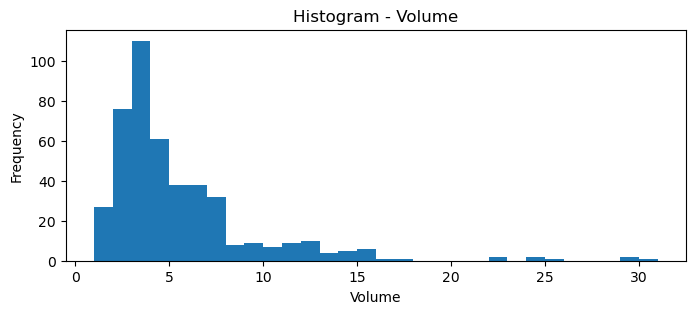

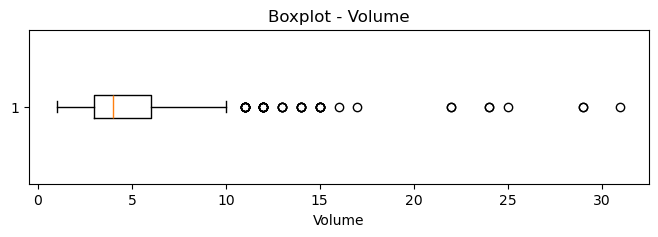

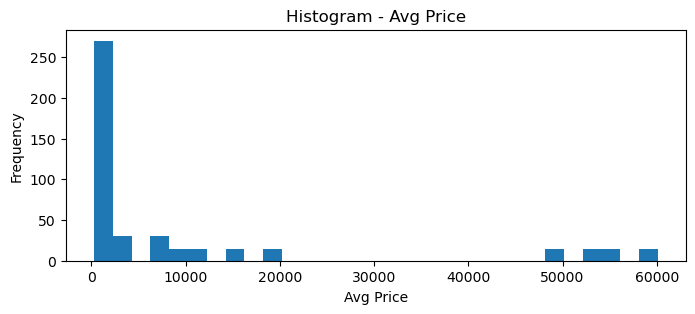

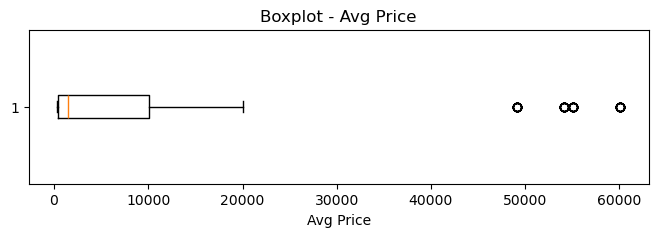

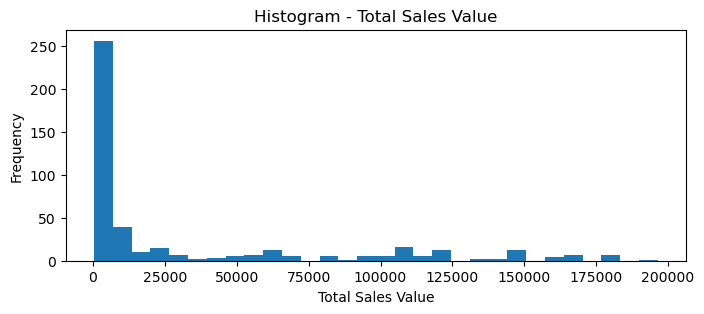

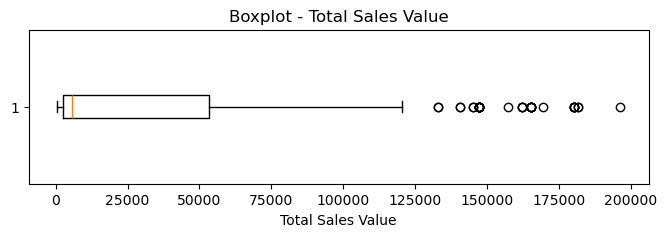

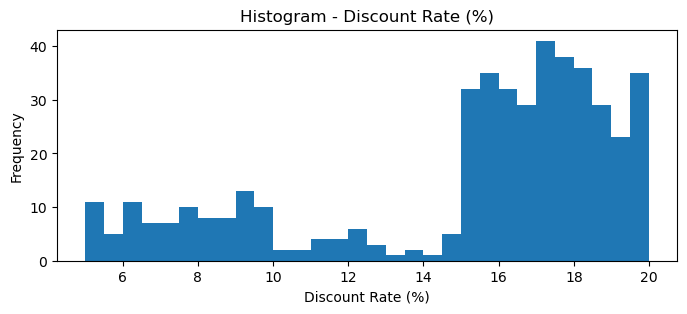

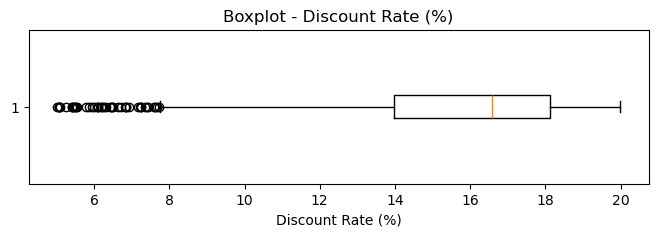

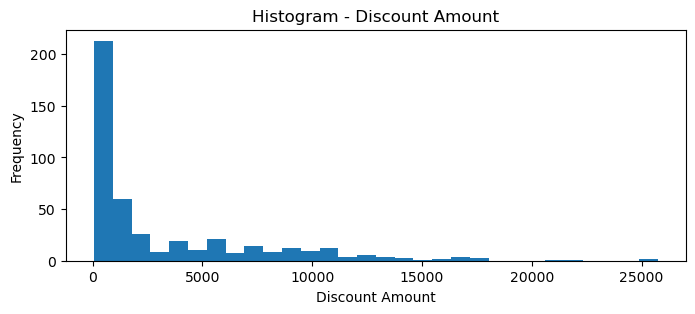

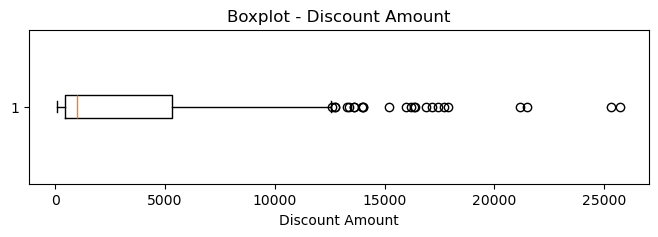

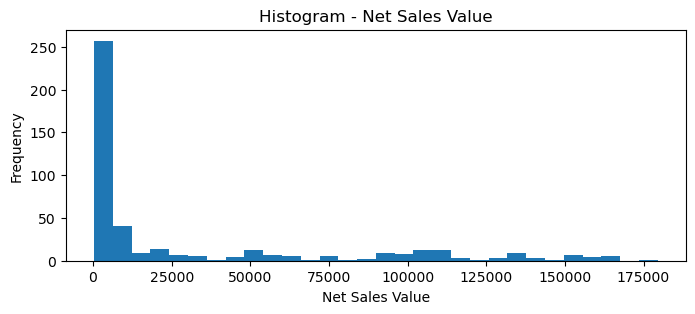

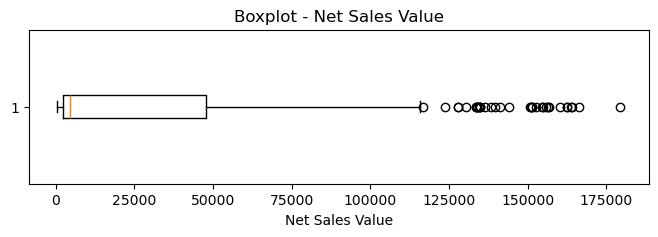

In [5]:
for col in num_cols:
    series = df[col].dropna()
    plt.figure(figsize=(8,3))
    plt.hist(series, bins=30)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(8,2))
    plt.boxplot(series, vert=False)
    plt.title(f'Boxplot - {col}')
    plt.xlabel(col)
    plt.show()

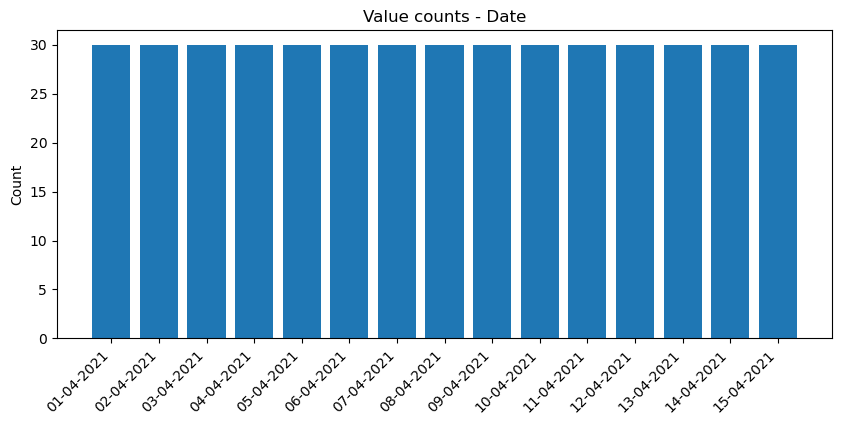

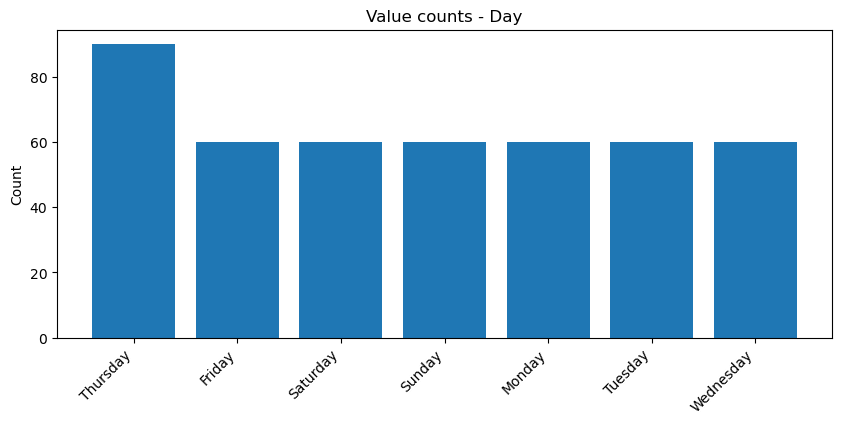

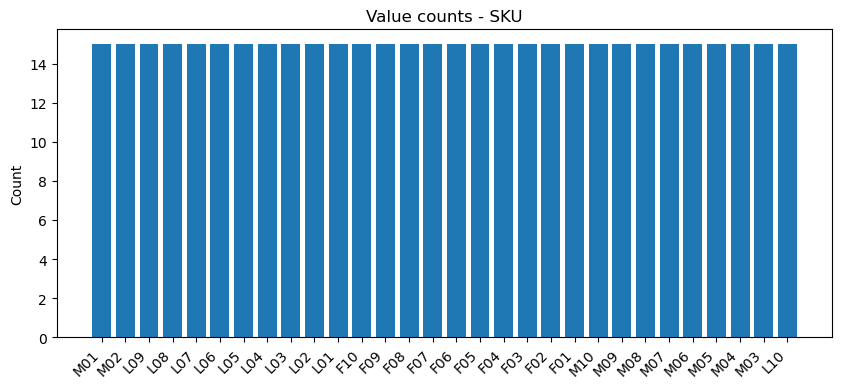

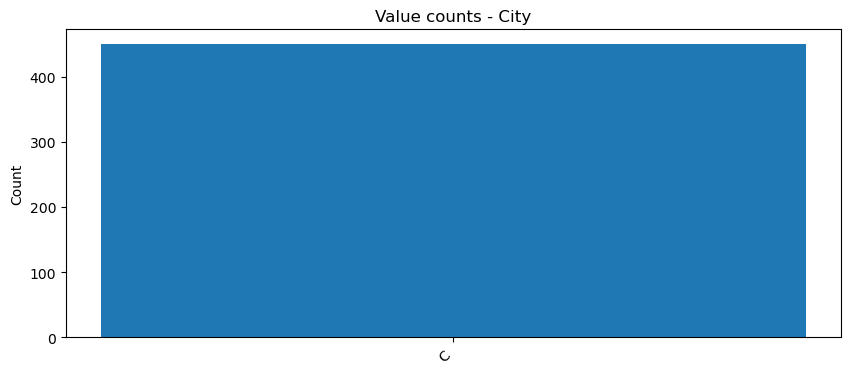

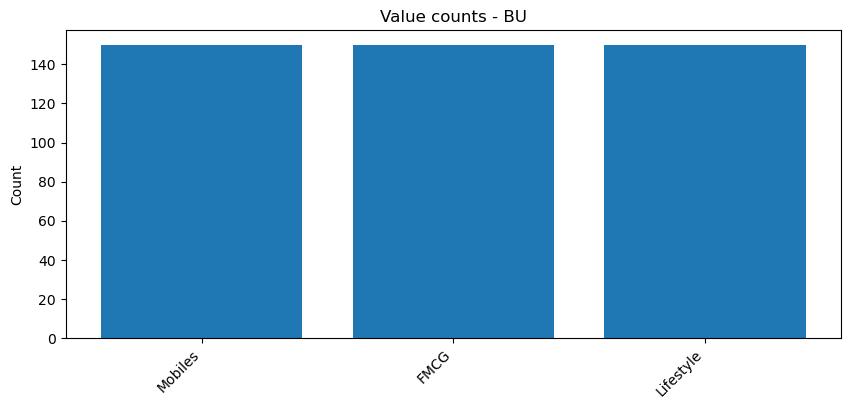

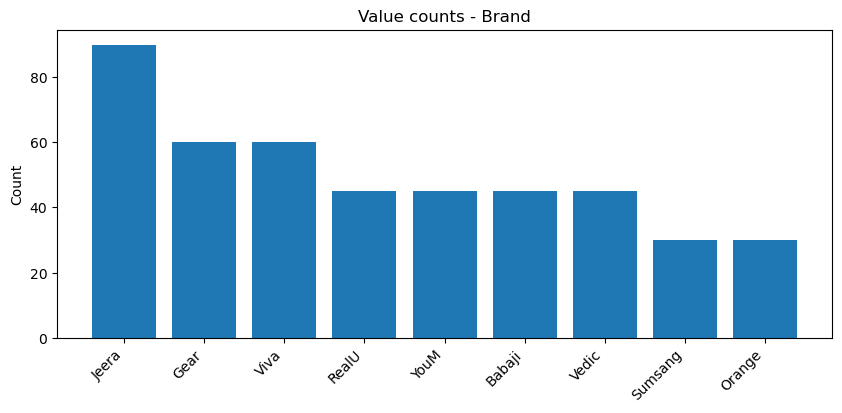

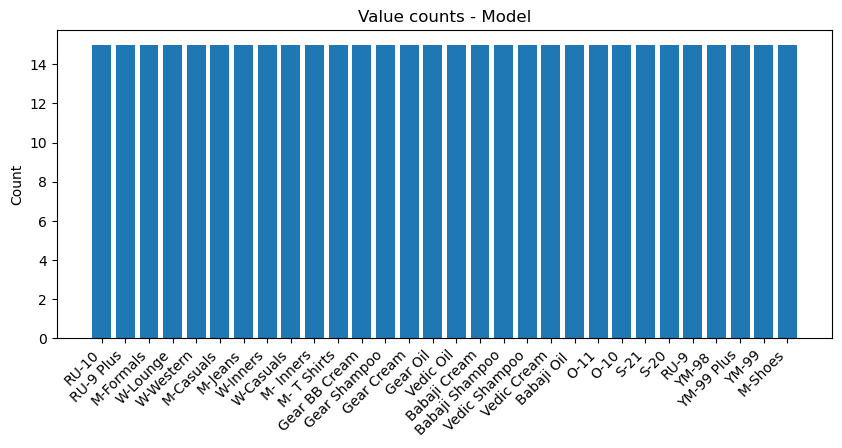

In [6]:
for col in cat_cols:
    counts = df[col].fillna('<<MISSING>>').value_counts()
    plt.figure(figsize=(10,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f'Value counts - {col}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')
    plt.show()

In [ ]:
from scipy import stats

standardized = df[num_cols].apply(lambda x: (x - x.mean()) / x.std(ddof=0))

standardized.head(10)

summary_std = pd.DataFrame({'mean': standardized.mean(), 'std': standardized.std(ddof=0)})
summary_std

,mean,std
Volume,5.723816e-17,1.0
Avg Price,3.552714e-17,1.0
Total Sales Value,1.973730e-17,1.0
Discount Rate (%),-2.960595e-17,1.0
Discount Amount,-6.315935e-17,1.0
Net Sales Value,1.578984e-17,1.0


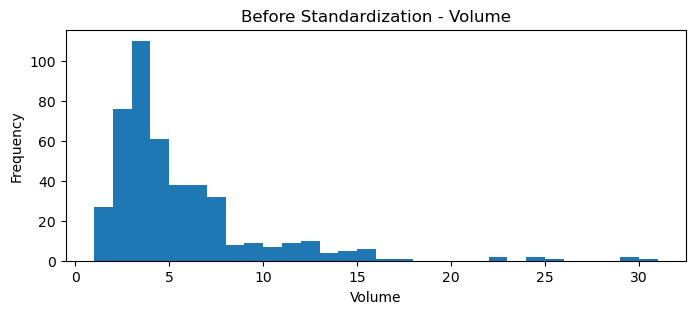

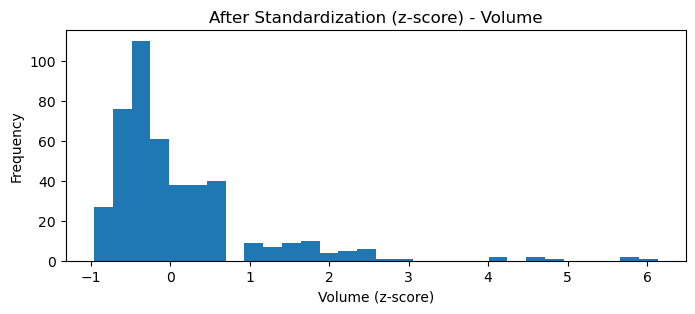

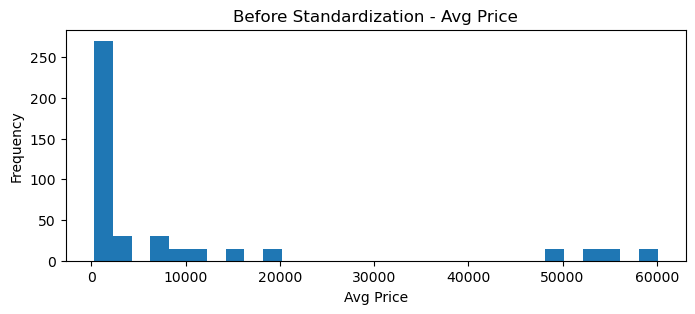

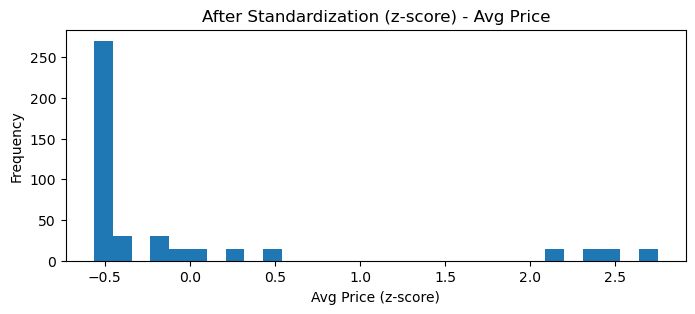

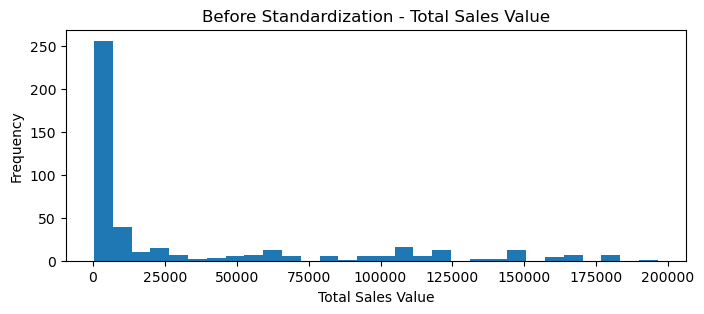

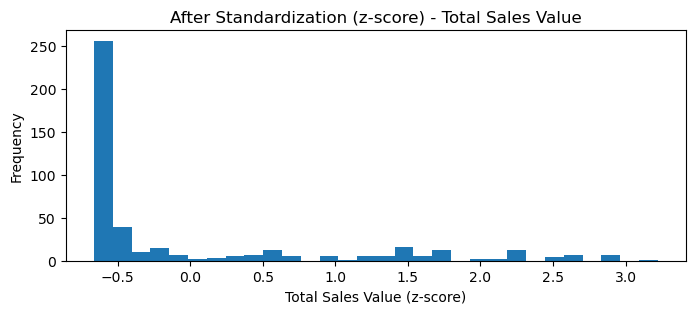

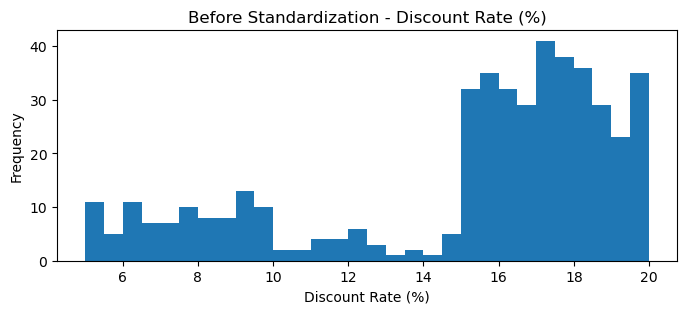

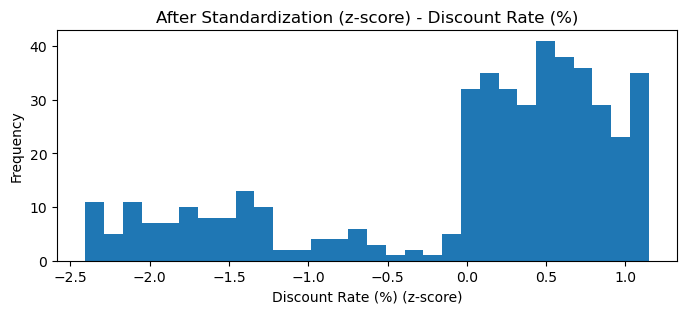

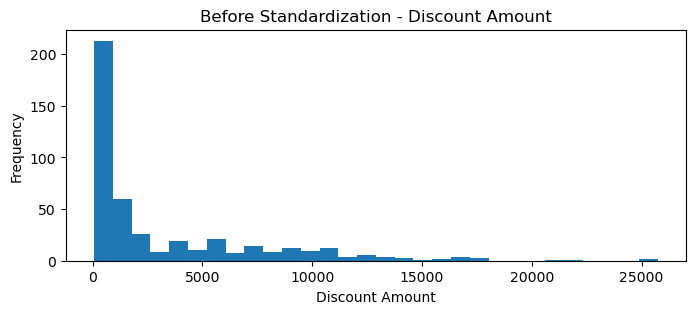

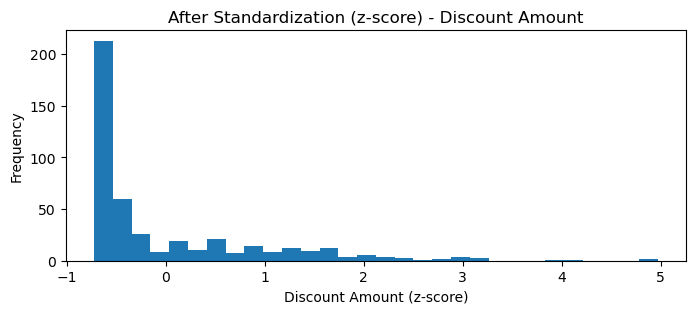

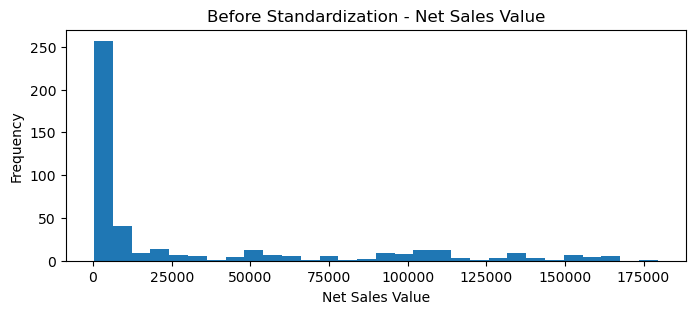

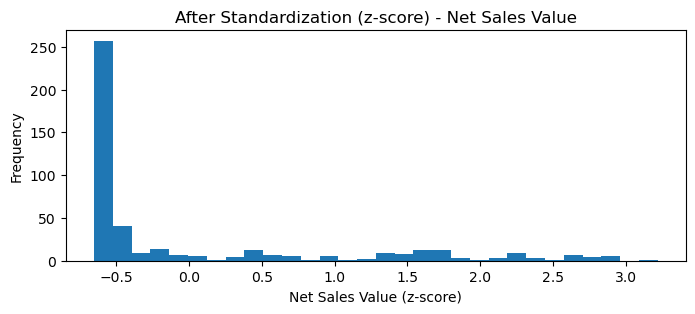

In [8]:
for col in num_cols:
    plt.figure(figsize=(8,3))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Before Standardization - {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(8,3))
    plt.hist(standardized[col].dropna(), bins=30)
    plt.title(f'After Standardization (z-score) - {col}')
    plt.xlabel(col + ' (z-score)')
    plt.ylabel('Frequency')
    plt.show()

In [9]:
df_dummies = pd.get_dummies(df, columns=cat_cols, drop_first=False)

print('Original shape:', df.shape)
print('Transformed shape:', df_dummies.shape)

df_dummies.head(10)

Original shape: (450, 13)
Transformed shape: (450, 101)


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Date_01-04-2021,Date_02-04-2021,Date_03-04-2021,Date_04-04-2021,...,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,15,12100,181500,11.654820,21153.498820,160346.501180,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,10,10100,101000,11.560498,11676.102961,89323.897039,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,7,16100,112700,9.456886,10657.910157,102042.089843,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,6,20100,120600,6.935385,8364.074702,112235.925298,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3,8100,24300,17.995663,4372.946230,19927.053770,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5,3,8100,24300,16.996489,4130.146805,20169.853195,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,3,49100,147300,9.228812,13594.039719,133705.960281,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,2,54100,108200,5.553719,6009.124321,102190.875679,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,2,55100,110200,7.410104,8165.935144,102034.064856,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,3,60100,180300,9.928444,17900.983733,162399.016267,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
output_path = 'D:\DS Assignment\Basic stats - 1\Basic stats - 1/sales_data_transformed.csv'
df_dummies.to_csv(output_path, index=False)
print('Transformed CSV saved to', output_path)

Transformed CSV saved to D:\DS Assignment\Basic stats - 1\Basic stats - 1/sales_data_transformed.csv
